<a href="https://colab.research.google.com/github/daniivelascoo/ifp-programacion-ia/blob/main/Teoria_2_2_A_Regresion_Lineal_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Teoría Bloque A: Regresión (La Bola de Cristal Numérica)
**Sprint 2.2 - Algoritmos de Machine Learning**

En IA, cuando la respuesta a tu pregunta es **un número** (¿Cuánto costará? ¿Cuánto lloverá? ¿Cuántos minutos tardaré?), estás ante un problema de **REGRESIÓN**.

El algoritmo más básico y fundamental es la **Regresión Lineal**. Intenta dibujar una línea recta perfecta que resuma la tendencia de los datos.

### 🎯 Objetivos:
1.  **Entender la Regresión:** Predecir cantidades continuas.
2.  **LinearRegression:** Entrenar el modelo matemático ($y = mx + b$).
3.  **Evaluación:** Medir el error en las mismas unidades que los datos (MAE).

## 1. El Problema: Experiencia vs. Salario

Imagina que tenemos datos de 6 empleados. Queremos saber: **¿Cuánto debería cobrar alguien con 7 años de experiencia?**

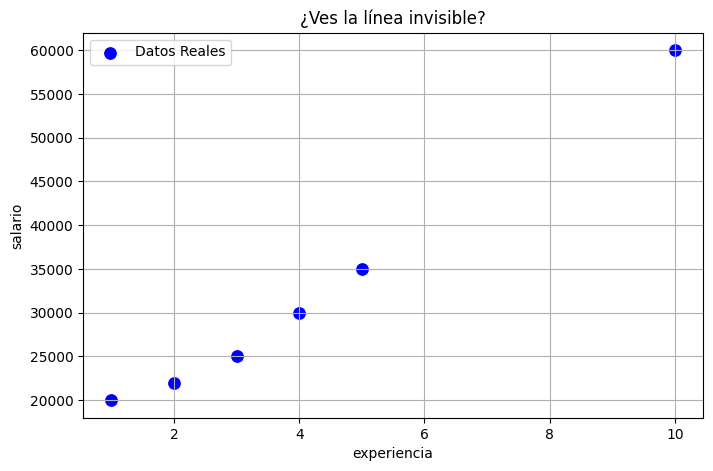

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Datos simples (Años -> Euros)
df = pd.DataFrame({
    'experiencia': [1, 2, 3, 4, 5, 10],
    'salario':     [20000, 22000, 25000, 30000, 35000, 60000]
})

# Visualizamos la tendencia
plt.figure(figsize=(8, 5))
# Puntos reales
sns.scatterplot(data=df, x='experiencia', y='salario', s=100, color='blue', label='Datos Reales')

plt.title("¿Ves la línea invisible?")
plt.grid(True)
plt.show()

## 2. Entrenando la Regresión Lineal

Vamos a pedirle a Scikit-Learn que encuentre la "Línea Recta" óptima.
Recuerda:
*   **X (Features):** Debe ser 2D (DataFrame).
*   **y (Target):** Debe ser 1D (Serie).

In [2]:
from sklearn.linear_model import LinearRegression

# 1. PREPARAR DATOS
# X debe ser DataFrame (doble corchete)
X = df[['experiencia']]
y = df['salario']

# 2. INSTANCIAR
# Creamos el modelo vacío
modelo = LinearRegression() # TODO: Llama a LinearRegression

# 3. ENTRENAR
print("🧠 Buscando la línea perfecta...")
modelo.fit(X, y) # TODO: Usa .fit()

print("¡Modelo entrenado!")
print(f"Intersección (Sueldo base hipotético): {modelo.intercept_:.2f} €")
print(f"Pendiente (Aumento por año): {modelo.coef_[0]:.2f} €")

🧠 Buscando la línea perfecta...
¡Modelo entrenado!
Intersección (Sueldo base hipotético): 12819.67 €
Pendiente (Aumento por año): 4603.28 €


## 3. Predicción (La Bola de Cristal)

Ahora podemos preguntar por valores que **no existen** en nuestros datos originales.
¿Cuánto cobraría alguien con 7 años? (No estaba en la tabla).

Para 7 años de experiencia, la IA estima: 45,042.62 €


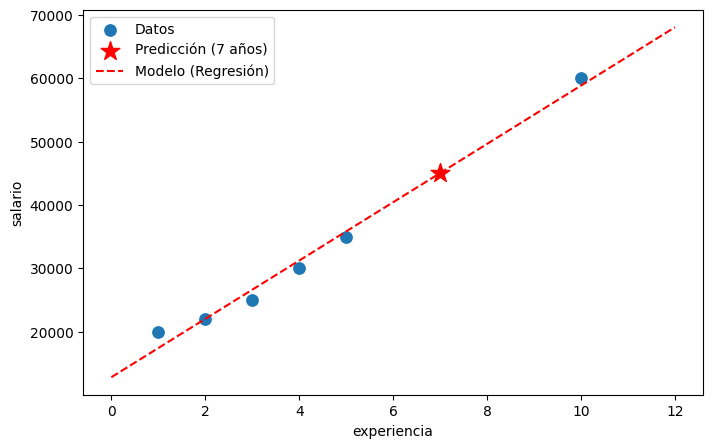

In [3]:
# Creamos el dato nuevo (Respetando el nombre de la columna para evitar warnings)
nuevo_empleado = pd.DataFrame({'experiencia': [7]})

# Predecimos
prediccion = modelo.predict(nuevo_empleado) # TODO: Usa .predict()

print(f"Para 7 años de experiencia, la IA estima: {prediccion[0]:,.2f} €")

# --- VISUALIZACIÓN DEL MODELO ---
# Vamos a pintar la línea que ha aprendido la IA sobre los datos
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='experiencia', y='salario', s=100, label='Datos')

# Pintamos la predicción como una estrella roja
plt.scatter(7, prediccion[0], color='red', s=200, marker='*', label='Predicción (7 años)')

# Pintamos la línea de tendencia completa
linea_x = pd.DataFrame({'experiencia': [0, 12]})
linea_y = modelo.predict(linea_x)
plt.plot(linea_x, linea_y, color='red', linestyle='--', label='Modelo (Regresión)')

plt.legend()
plt.show()

## 4. Evaluación: ¿Cuánto nos equivocamos?

En regresión, no existe el "Aprobado/Suspenso". Existe el **Error**.
Usamos el **MAE (Mean Absolute Error)**: El Error Medio Absoluto.
Significa: *"De media, la IA se equivoca en X euros hacia arriba o hacia abajo"*.

In [4]:
from sklearn.metrics import mean_absolute_error

# 1. Predecimos sobre los datos originales para ver qué tal lo hace
y_pred = modelo.predict(X)

# 2. Calculamos el MAE
# Comparamos la Realidad (y) con la Predicción (y_pred)
error = mean_absolute_error(y, y_pred) # TODO: Pasa (y, y_pred)

print(f"El salario real medio es: {y.mean():,.2f} €")
print(f"El error medio del modelo es: {error:,.2f} €")

# Reflexión:
# Si el error es pequeño comparado con la media, el modelo es bueno.
# 1.400€ de error en un sueldo de 32.000€ es un error del ~4%. ¡Bastante bien!

El salario real medio es: 32,000.00 €
El error medio del modelo es: 1,241.53 €
